# 01 - Exploratory Data Analysis (EDA)

Este notebook realiza un análisis exploratorio inicial del dataset sintético de churn en un entorno SaaS tipo martech.

Objetivos:
- revisar la estructura general de los datos,
- validar la distribución de la variable objetivo,
- explorar patrones de churn por segmento y variables clave,
- identificar señales relevantes para el modelado posterior,
- generar tablas y gráficos reutilizables en el TFM.


## 1. Importación de librerías

In [24]:
import os
from pathlib import Path

print("Carpeta actual del notebook:")
print(Path.cwd())

print("\nArchivos en la carpeta actual:")
print(os.listdir("."))

Carpeta actual del notebook:
/Users/javierpinilla/Documents/Project Website with ChatGPT/tfm_churn_project

Archivos en la carpeta actual:
['generate_dataset.py', 'synthetic_saas_churn_dataset.csv', '01_eda_synthetic_saas_churn.ipynb', '02_model_training_comparison.ipynb', 'best_churn_model.pkl']


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)


## 2. Carga del dataset

Ajusta la ruta si el archivo CSV se encuentra en otra carpeta.


In [26]:
import pandas as pd

file_path = "synthetic_saas_churn_dataset.csv"
df = pd.read_csv(file_path)

print("Shape del dataset:", df.shape)
df.head()


Shape del dataset: (2500, 30)


,account_id,segment,subscription_type,plan_tier,tenure_months,mrr,bundles_contracted,extra_users,renewal_due_days,subscription_status,renewed_last_quarter,renewal_intent,in_grace_period,login_count_30d,tool_activity_score,usage_change_vs_prev_quarter,feature_adoption_score,key_reports_used_30d,days_since_last_login,emails_with_csm_30d,csm_meetings_last_quarter,strategic_review_done,success_plan_active,tickets_last_quarter,reopened_tickets,avg_resolution_days,csat_support,sentiment_csm,sentiment_support,churn_label
0,ACC_00001,SMB,monthly,Pro,4,54.84,1,1,164,active,0,neutral,0,24,17.2,-16.5,0.0,8,7,7,2,0,1,5,1,6.7,3.5,-0.02,-0.14,0
1,ACC_00002,Enterprise,monthly,Enterprise,39,9793.65,4,12,51,churned,0,positive,0,59,52.6,25.0,43.6,18,11,9,2,0,0,2,0,3.1,4.0,0.28,0.30,0
2,ACC_00003,Mid-Market,annual,Business,7,1805.48,2,4,74,churned,0,positive,0,54,30.6,18.4,7.1,16,0,5,0,0,1,4,1,7.4,3.7,-0.28,0.18,0
3,ACC_00004,SMB,monthly,Pro,33,156.14,1,1,91,churned,0,negative,0,20,3.0,6.2,9.8,5,27,1,0,0,1,4,0,6.2,2.9,-0.16,-0.36,1
4,ACC_00005,SMB,annual,Guru,5,334.60,1,0,61,churned,0,positive,0,14,9.7,-16.5,8.6,8,23,1,0,0,1,6,1,4.2,3.5,-0.26,-0.45,0


## 3. Revisión general de la estructura

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   account_id                    2500 non-null   object 
 1   segment                       2500 non-null   object 
 2   subscription_type             2500 non-null   object 
 3   plan_tier                     2500 non-null   object 
 4   tenure_months                 2500 non-null   int64  
 5   mrr                           2500 non-null   float64
 6   bundles_contracted            2500 non-null   int64  
 7   extra_users                   2500 non-null   int64  
 8   renewal_due_days              2500 non-null   int64  
 9   subscription_status           2500 non-null   object 
 10  renewed_last_quarter          2500 non-null   int64  
 11  renewal_intent                2500 non-null   object 
 12  in_grace_period               2500 non-null   int64  
 13  log

In [28]:
df.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
account_id,2500,2500,ACC_00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
segment,2500,3,SMB,1486,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subscription_type,2500,2,annual,1630,NaN,NaN,NaN,NaN,NaN,NaN,NaN
plan_tier,2500,4,Pro,980,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure_months,2500.0,NaN,NaN,NaN,21.8712,12.747628,1.0,12.0,21.0,31.0,60.0
mrr,2500.0,NaN,NaN,NaN,985.402104,2045.259319,50.0,163.215,339.79,645.6475,17832.18
bundles_contracted,2500.0,NaN,NaN,NaN,2.1436,1.056894,1.0,1.0,2.0,3.0,6.0
extra_users,2500.0,NaN,NaN,NaN,2.9488,3.602578,0.0,1.0,2.0,4.0,23.0
renewal_due_days,2500.0,NaN,NaN,NaN,91.2036,51.848432,0.0,47.0,93.0,136.0,180.0
subscription_status,2500,3,churned,1842,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Comprobación de valores nulos y duplicados

In [29]:
nulls = df.isnull().sum().sort_values(ascending=False)
print('Valores nulos por columna:')
print(nulls[nulls > 0])

print('\nNúmero de account_id duplicados:', df['account_id'].duplicated().sum())


Valores nulos por columna:
Series([], dtype: int64)

Número de account_id duplicados: 0


## 5. Distribución de la variable objetivo

In [30]:
churn_dist = df['churn_label'].value_counts().sort_index()
churn_pct = df['churn_label'].value_counts(normalize=True).sort_index() * 100

summary_churn = pd.DataFrame({
    'count': churn_dist,
    'percentage': churn_pct.round(2)
})
summary_churn.index = ['No churn (0)', 'Churn (1)']
summary_churn


,count,percentage
No churn (0),1694,67.76
Churn (1),806,32.24


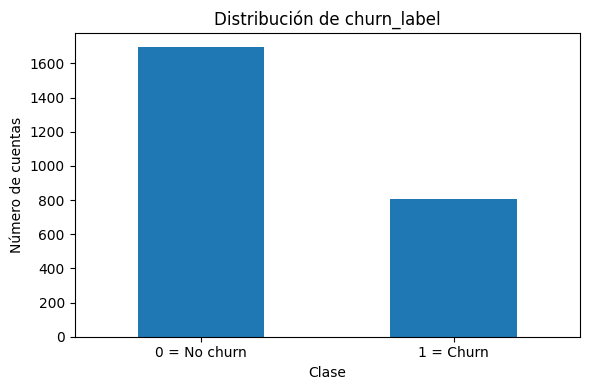

In [31]:
plt.figure(figsize=(6,4))
churn_dist.plot(kind='bar')
plt.title('Distribución de churn_label')
plt.xlabel('Clase')
plt.ylabel('Número de cuentas')
plt.xticks([0,1], ['0 = No churn', '1 = Churn'], rotation=0)
plt.tight_layout()
plt.show()


## 6. Métricas de negocio agregadas

In [32]:
churn_rate = df['churn_label'].mean()
retention_rate = ((df['renewed_last_quarter'] == 1) | (df['subscription_status'] == 'active')).mean()

business_metrics = pd.DataFrame({
    'metric': ['Quarterly churn rate', 'Quarterly retention rate'],
    'value': [round(churn_rate * 100, 2), round(retention_rate * 100, 2)]
})
business_metrics


,metric,value
0,Quarterly churn rate,32.24
1,Quarterly retention rate,24.80


## 7. Distribución por segmento, tipo de suscripción y plan

In [33]:
for col in ['segment', 'subscription_type', 'plan_tier', 'renewal_intent', 'subscription_status']:
    print(f'\n===== {col} =====')
    print(df[col].value_counts())



===== segment =====
segment
SMB           1486
Mid-Market     769
Enterprise     245
Name: count, dtype: int64

===== subscription_type =====
subscription_type
annual     1630
monthly     870
Name: count, dtype: int64

===== plan_tier =====
plan_tier
Pro           980
Guru          895
Business      477
Enterprise    148
Name: count, dtype: int64

===== renewal_intent =====
renewal_intent
neutral     1052
negative     916
positive     532
Name: count, dtype: int64

===== subscription_status =====
subscription_status
churned            1842
active              600
renewal_pending      58
Name: count, dtype: int64


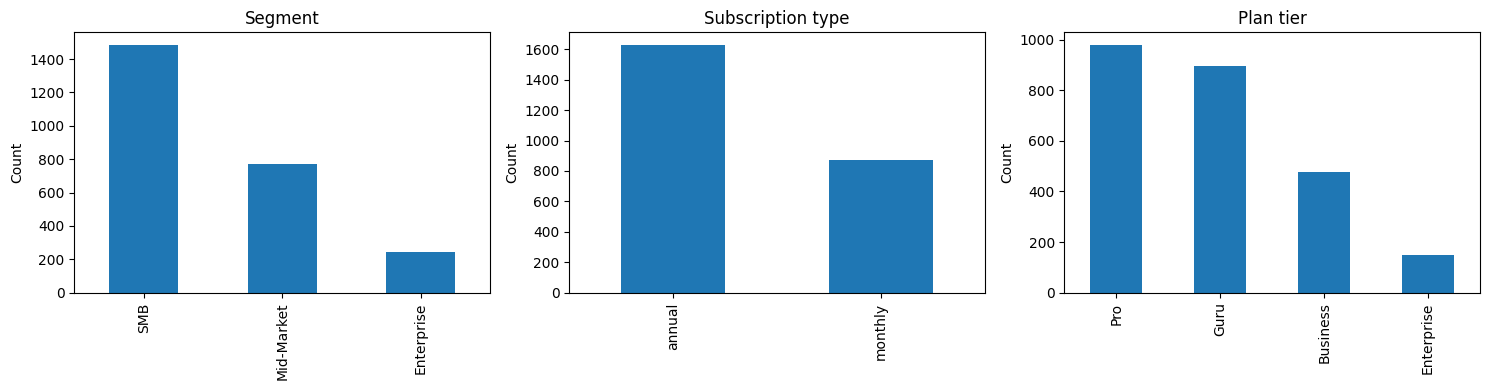

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['segment'].value_counts().plot(kind='bar', ax=axes[0], title='Segment')
df['subscription_type'].value_counts().plot(kind='bar', ax=axes[1], title='Subscription type')
df['plan_tier'].value_counts().plot(kind='bar', ax=axes[2], title='Plan tier')

for ax in axes:
    ax.set_xlabel('')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


## 8. Tasa de churn por categorías relevantes

In [35]:
def churn_by_category(df, col):
    result = df.groupby(col)['churn_label'].agg(['count', 'mean']).sort_values('mean', ascending=False)
    result['churn_rate_pct'] = (result['mean'] * 100).round(2)
    return result[['count', 'churn_rate_pct']]

for col in ['segment', 'subscription_type', 'plan_tier', 'renewal_intent', 'subscription_status']:
    print(f'\n===== Churn por {col} =====')
    print(churn_by_category(df, col))



===== Churn por segment =====
            count  churn_rate_pct
segment                          
SMB          1486           37.48
Mid-Market    769           27.83
Enterprise    245           14.29

===== Churn por subscription_type =====
                   count  churn_rate_pct
subscription_type                       
monthly              870           34.60
annual              1630           30.98

===== Churn por plan_tier =====
            count  churn_rate_pct
plan_tier                        
Pro           980           38.98
Guru          895           32.63
Business      477           22.85
Enterprise    148           15.54

===== Churn por renewal_intent =====
                count  churn_rate_pct
renewal_intent                       
negative          916           87.99
neutral          1052            0.00
positive          532            0.00

===== Churn por subscription_status =====
                     count  churn_rate_pct
subscription_status                       


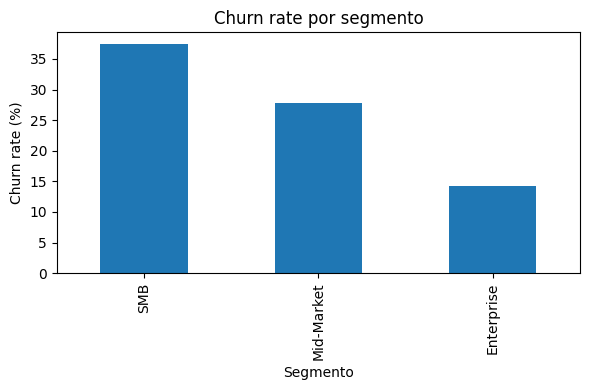

In [36]:
churn_segment = df.groupby('segment')['churn_label'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(6,4))
churn_segment.plot(kind='bar')
plt.title('Churn rate por segmento')
plt.ylabel('Churn rate (%)')
plt.xlabel('Segmento')
plt.tight_layout()
plt.show()


## 9. Comparación de variables numéricas entre churn y no churn

In [37]:
numeric_cols = [
    'tenure_months', 'mrr', 'bundles_contracted', 'extra_users', 'renewal_due_days',
    'login_count_30d', 'tool_activity_score', 'usage_change_vs_prev_quarter',
    'feature_adoption_score', 'key_reports_used_30d', 'days_since_last_login',
    'emails_with_csm_30d', 'csm_meetings_last_quarter', 'tickets_last_quarter',
    'reopened_tickets', 'avg_resolution_days', 'csat_support',
    'sentiment_csm', 'sentiment_support'
]

comparison = df.groupby('churn_label')[numeric_cols].mean().transpose()
comparison.columns = ['No churn (0)', 'Churn (1)']
comparison['Difference'] = comparison['Churn (1)'] - comparison['No churn (0)']
comparison.sort_values('Difference')


,No churn (0),Churn (1),Difference
mrr,1146.273530,647.292680,-498.980850
usage_change_vs_prev_quarter,-9.039256,-19.153970,-10.114714
login_count_30d,29.871311,24.007444,-5.863866
tool_activity_score,24.554132,19.293424,-5.260708
feature_adoption_score,25.575915,21.563648,-4.012267
key_reports_used_30d,9.077922,7.024814,-2.053108
tenure_months,22.422668,20.712159,-1.710509
extra_users,3.289256,2.233251,-1.056006
emails_with_csm_30d,4.871901,4.031017,-0.840883
bundles_contracted,2.244392,1.931762,-0.312630


## 10. Visualizaciones clave para el TFM

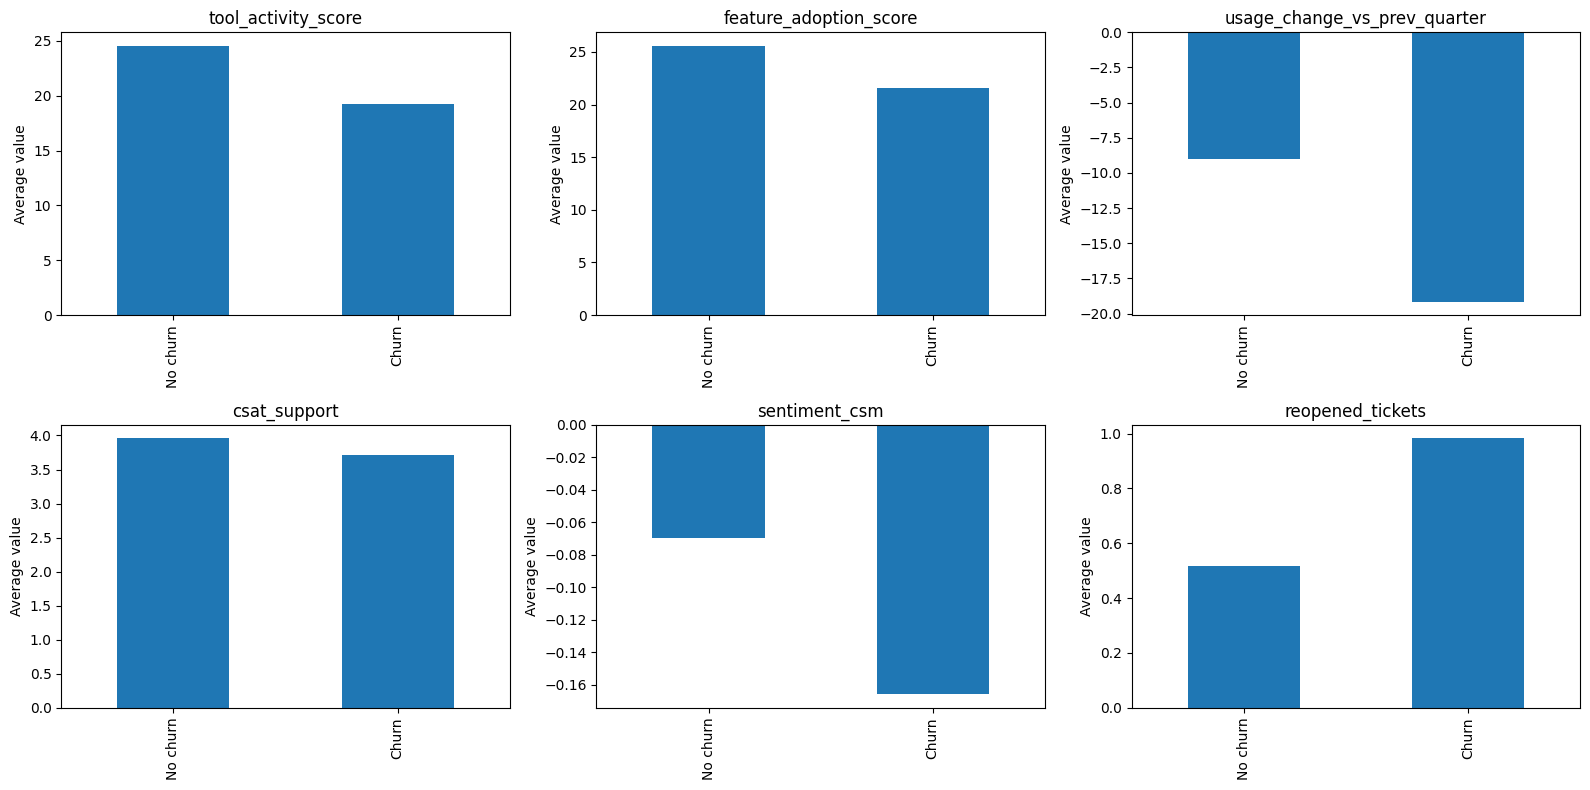

In [38]:
key_metrics = [
    'tool_activity_score',
    'feature_adoption_score',
    'usage_change_vs_prev_quarter',
    'csat_support',
    'sentiment_csm',
    'reopened_tickets'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(key_metrics):
    means = df.groupby('churn_label')[col].mean()
    means.index = ['No churn', 'Churn']
    means.plot(kind='bar', ax=axes[i], title=col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Average value')

plt.tight_layout()
plt.show()


## 11. Correlación entre variables numéricas

La correlación no implica causalidad, pero ayuda a identificar señales que parecen moverse junto al churn.


In [39]:
corr_cols = numeric_cols + ['churn_label']
corr = df[corr_cols].corr(numeric_only=True)['churn_label'].sort_values(ascending=False)
corr


churn_label                     1.000000
reopened_tickets                0.257227
avg_resolution_days             0.203047
tickets_last_quarter            0.181970
days_since_last_login           0.063040
renewal_due_days                0.014163
tenure_months                  -0.062729
csm_meetings_last_quarter      -0.092931
emails_with_csm_30d            -0.101550
mrr                            -0.114053
extra_users                    -0.137033
feature_adoption_score         -0.137866
bundles_contracted             -0.138284
key_reports_used_30d           -0.154534
login_count_30d                -0.158102
sentiment_csm                  -0.164483
tool_activity_score            -0.165212
sentiment_support              -0.239682
usage_change_vs_prev_quarter   -0.242517
csat_support                   -0.247943
Name: churn_label, dtype: float64

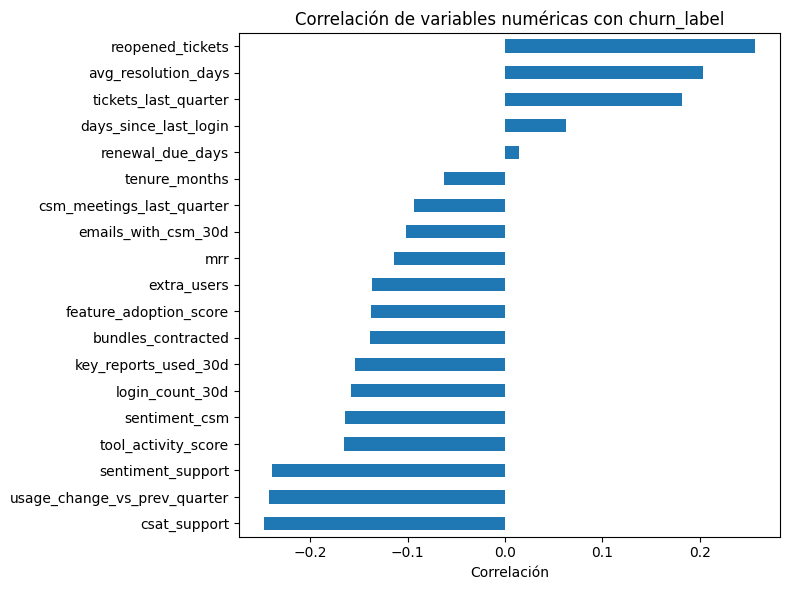

In [40]:
plt.figure(figsize=(8,6))
corr.drop('churn_label').sort_values().plot(kind='barh')
plt.title('Correlación de variables numéricas con churn_label')
plt.xlabel('Correlación')
plt.tight_layout()
plt.show()


## 12. Segmentación simple de cuentas de riesgo

Esta parte no sustituye al modelo predictivo, pero ayuda a observar patrones tempranos.


In [41]:
risk_snapshot = df.copy()

risk_snapshot['low_activity_flag'] = (risk_snapshot['tool_activity_score'] < 35).astype(int)
risk_snapshot['low_adoption_flag'] = (risk_snapshot['feature_adoption_score'] < 40).astype(int)
risk_snapshot['negative_sentiment_flag'] = (risk_snapshot['sentiment_csm'] < -0.2).astype(int)
risk_snapshot['poor_support_flag'] = (risk_snapshot['csat_support'] < 3.2).astype(int)
risk_snapshot['renewal_risk_flag'] = ((risk_snapshot['renewal_due_days'] < 30) & (risk_snapshot['renewal_intent'] == 'negative')).astype(int)

risk_snapshot['simple_risk_signals'] = risk_snapshot[
    ['low_activity_flag', 'low_adoption_flag', 'negative_sentiment_flag', 'poor_support_flag', 'renewal_risk_flag']
].sum(axis=1)

risk_snapshot.groupby('simple_risk_signals')['churn_label'].agg(['count', 'mean'])


,count,mean
simple_risk_signals,,
0,187,0.058824
1,307,0.169381
2,1006,0.295229
3,895,0.410056
4,101,0.742574
5,4,1.000000


## 13. Tabla resumen para usar en la memoria

In [42]:
summary_table = pd.DataFrame({
    'metric': [
        'Total accounts',
        'Quarterly churn rate (%)',
        'Quarterly retention rate (%)',
        'Average activity score',
        'Average feature adoption score',
        'Average CSAT support',
        'Average sentiment with CSM'
    ],
    'value': [
        len(df),
        round(df['churn_label'].mean() * 100, 2),
        round((((df['renewed_last_quarter'] == 1) | (df['subscription_status'] == 'active')).mean()) * 100, 2),
        round(df['tool_activity_score'].mean(), 2),
        round(df['feature_adoption_score'].mean(), 2),
        round(df['csat_support'].mean(), 2),
        round(df['sentiment_csm'].mean(), 2)
    ]
})

summary_table


,metric,value
0,Total accounts,2500.00
1,Quarterly churn rate (%),32.24
2,Quarterly retention rate (%),24.80
3,Average activity score,22.86
4,Average feature adoption score,24.28
5,Average CSAT support,3.88
6,Average sentiment with CSM,-0.10


## 14. Conclusiones iniciales del EDA

Puntos que puedes adaptar luego a la memoria:

- El dataset presenta una estructura coherente para abordar un problema de churn en un entorno SaaS.
- La variable objetivo muestra una distribución plausible y no completamente equilibrada, lo que se asemeja a un escenario real.
- Existen diferencias visibles entre cuentas churned y no churned en variables como actividad, adopción, satisfacción y sentimiento.
- Las señales relacionadas con uso reciente, renovación, sentimiento y experiencia de soporte parecen especialmente relevantes para el modelado.
- El análisis exploratorio valida que el problema puede abordarse mediante modelos predictivos en la siguiente fase del proyecto.
